# Feature Engineering
This section creates business-relevant features that help explain customer satisfaction patterns.

Feature engineering helps:
- Improve model predictive performance
- Capture hidden relationships between variables
- Represent categorical interactions meaningfully
- Create more informative behavioral indicators

The goal is to transform cleaned restaurant-user interaction attributes into model-ready features that better explain restaurant rating behaviour and dining preference patterns for predictive recommendation modelling.

In [23]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt




## Load Cleaned Dataset

In [2]:
df = pd.read_csv("../data/processed/chefmoz_clean.csv")
df.head()

,userid,placeid,rating,food_rating,service_rating,latitude,longitude,smoker,drink_level,dress_preference,...,color,weight,budget,height,rcuisine_x,rcuisine_y,rpayment,parking_lot,hours,days
0,u1077,135085,2,2,2,22.156469,-100.985540,False,social drinker,elegant,...,blue,65.0,medium,1.71,mexican,fast_food,cash,public,00:00-00:00;,"mon, tue, wed, thu, fri,"
1,u1077,135038,2,2,1,22.156469,-100.985540,False,social drinker,elegant,...,blue,65.0,medium,1.71,mexican,unknown,cash,none,08:00-17:00;,"mon, tue, wed, thu, fri,"
2,u1077,132825,2,2,2,22.156469,-100.985540,False,social drinker,elegant,...,blue,65.0,medium,1.71,mexican,mexican,cash,none,09:00-12:00;,"mon, tue, wed, thu, fri,"
3,u1077,135060,1,2,2,22.156469,-100.985540,False,social drinker,elegant,...,blue,65.0,medium,1.71,mexican,seafood,cash,none,11:30-19:00;,"mon, tue, wed, thu, fri,"
4,u1015,135071,0,0,0,22.126760,-100.905209,True,social drinker,informal,...,black,87.0,medium,1.67,mexican,bar,cash,yes,13:00-23:30;,"mon, tue, wed, thu, fri,"


In [3]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 847 entries, 0 to 846
Data columns (total 29 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   userid            847 non-null    object 
 1   placeid           847 non-null    int64  
 2   rating            847 non-null    int64  
 3   food_rating       847 non-null    int64  
 4   service_rating    847 non-null    int64  
 5   latitude          847 non-null    float64
 6   longitude         847 non-null    float64
 7   smoker            820 non-null    object 
 8   drink_level       847 non-null    object 
 9   dress_preference  811 non-null    object 
 10  ambience          847 non-null    object 
 11  transport         847 non-null    object 
 12  marital_status    847 non-null    object 
 13  hijos             847 non-null    object 
 14  birth_year        847 non-null    int64  
 15  interest          847 non-null    object 
 16  personality       847 non-null    object 
 1

,placeid,rating,food_rating,service_rating,latitude,longitude,birth_year,weight,height
count,847.000000,847.000000,847.000000,847.000000,847.000000,847.000000,847.000000,847.000000,847.000000
mean,134327.394333,1.212515,1.210153,1.105077,22.156251,-100.964872,1984.461629,61.587072,1.669723
std,1042.150886,0.763954,0.782939,0.783736,0.020340,0.030870,16.220281,14.110559,0.113566
min,132572.000000,0.000000,0.000000,0.000000,22.118464,-101.028373,1930.000000,40.000000,1.375000
25%,132884.000000,1.000000,1.000000,0.000000,22.143183,-100.986843,1988.000000,51.500000,1.600000
50%,135041.000000,1.000000,1.000000,1.000000,22.150891,-100.975342,1990.000000,65.000000,1.690000
75%,135062.000000,2.000000,2.000000,2.000000,22.169184,-100.940664,1991.000000,70.000000,1.750000
max,135108.000000,2.000000,2.000000,2.000000,22.207749,-100.900536,1992.000000,97.750000,1.975000


## Feature Engineering: Categorical Encoding

This section focuses on transforming categorical variables into numerical formats suitable for machine learning models. 

The following target variables will be encoded:
* **Demographics**: `marital_status`, `education`, `occupation`, `hijos` , `religion`
* **User Profile**: `personality`, `activity`
* **Preferences / Environment**: `ambience`, `transport`


In [4]:
df = pd.get_dummies(df, columns=['marital_status', 'personality'], drop_first=True)

## Handling Rare Categories

To improve model stability, low-frequency categories with insufficient data distribution will be aggregated into a broader `"Other"` category.


In [5]:
value_counts = df['activity'].value_counts()

rare = value_counts[value_counts < 20].index
df['activity'] = df['activity'].replace(rare, 'Other')

In [43]:
# Feature Engineering

# Handle baseline NaNs in raw columns before engineering
# We fill missing ratings with their column medians
df['food_rating'] = df['food_rating'].fillna(df['food_rating'].median())
df['service_rating'] = df['service_rating'].fillna(df['service_rating'].median())

# Handle missing budget values by assigning the most common category ('medium')
df['budget'] = df['budget'].fillna('medium')


# Feature Generation 

# Encode budget into numeric scale
budget_map = {'low': 1, 'medium': 2, 'high': 3}
# Use .fillna(2) as a fallback mechanism for budget mapping anomalies
df['budget_numeric'] = df['budget'].map(budget_map).fillna(2)

# 1. Family-Activity Compatibility
df['family_activity_match'] = (
    (df['hijos'] == 'kids') &
    (df['activity'].isin(['student', 'professional']))
).astype(int)

# 2. Budget-Service Value Score
df['budget_service_score'] = df['service_rating'] * df['budget_numeric']

# 3. Dining Experience Score
df['dining_experience_score'] = (df['food_rating'] + df['service_rating']) / 2

# 4. Location Score
# Fill any rare missing location data with column medians before math operations
df['latitude'] = df['latitude'].fillna(df['latitude'].median())
df['longitude'] = df['longitude'].fillna(df['longitude'].median())
df['location_score'] = abs(df['latitude']) + abs(df['longitude'])

# 5. Cuisine Match Indicator
df['cuisine_match'] = (df['rcuisine_x'] == df['rcuisine_y']).astype(int)

# 6. Accessibility Score
transport_map = {'public': 2, 'car owner': 3, 'on foot': 1}
parking_map = {'yes': 1, 'none': 0, 'public': 1}

df['accessibility_score'] = (
    df['transport'].map(transport_map).fillna(0) +
    df['parking_lot'].map(parking_map).fillna(0)
)

# 7. Social Dining Score
# pd.factorize automatically assigns -1 to missing values. We convert -1 to 0 to keep scales clean.
df['social_dining_score'] = (
    pd.factorize(df['drink_level'])[0] +
    pd.factorize(df['ambience'])[0]
).clip(0) 


# --- Final Pipeline Verification ---
engineered_features = [
    'budget_numeric', 'family_activity_match', 'budget_service_score',
    'dining_experience_score', 'location_score', 'cuisine_match',
    'accessibility_score', 'social_dining_score'
]

print("Missing values per engineered feature:")
print(df[engineered_features].isna().sum())

Missing values per engineered feature:
budget_numeric             0
family_activity_match      0
budget_service_score       0
dining_experience_score    0
location_score             0
cuisine_match              0
accessibility_score        0
social_dining_score        0
dtype: int64


In [44]:
print(df['budget'].unique())

['medium' 'low' 'high']


## Feature Engineering Summary

The following behavioral and contextual features were engineered to improve predictive modeling performance:

* **`family_activity_match`** → Captures family-context alignment.
* **`budget_service_score`** → Reflects value-for-money perception.
* **`dining_experience_score`** → Aggregates food and service quality.
* **`location_score`** → Captures spatial influence.
* **`cuisine_match`** → Identifies cuisine preference alignment.
* **`accessibility_score`** → Measures convenience of access.
* **`social_dining_score`** → Captures social dining behavior.

These engineered features align directly with the project objective of optimizing restaurant rating predictions and recommendation system performance.


## Baseline Model Development
The purpose of the baseline model is to establish an initial performance benchmark.

This model provides:

- A reference score for future model improvements
- A simple interpretable benchmark
- Validation that the feature engineering pipeline is functional

For this project, we begin with a basic classification model before moving to more complex algorithms.

### Prepare Features and Target

In [45]:
# Define feature matrix
feature_cols = [
    'budget_numeric',
    'family_activity_match',
    'budget_service_score',
    'dining_experience_score',
    'location_score',
    'cuisine_match',
    'accessibility_score',
    'social_dining_score'
]

X = df[feature_cols]

# Define target
y = df['rating']   # replace if your actual target name differs

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

print("\nFeatures selected:")
print(X.columns.tolist())

Feature shape: (847, 8)
Target shape: (847,)

Features selected:
['budget_numeric', 'family_activity_match', 'budget_service_score', 'dining_experience_score', 'location_score', 'cuisine_match', 'accessibility_score', 'social_dining_score']


### Train-Test Split

In [46]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y  # <--- Keeps distributions identical
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (677, 8)
Testing set: (170, 8)


### Verify class imbalance

In [47]:
print(y_train.value_counts())
print(y_test.value_counts())

rating
2    284
1    252
0    141
Name: count, dtype: int64
rating
2    72
1    63
0    35
Name: count, dtype: int64


In [48]:
baseline_model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)

baseline_model.fit(X_train, y_train)
y_pred = baseline_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print("Baseline Accuracy:", accuracy)
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Baseline Accuracy: 0.7235294117647059

Classification Report:

              precision    recall  f1-score   support

           0       0.67      0.89      0.77        35
           1       0.72      0.54      0.62        63
           2       0.75      0.81      0.78        72

    accuracy                           0.72       170
   macro avg       0.72      0.74      0.72       170
weighted avg       0.73      0.72      0.72       170



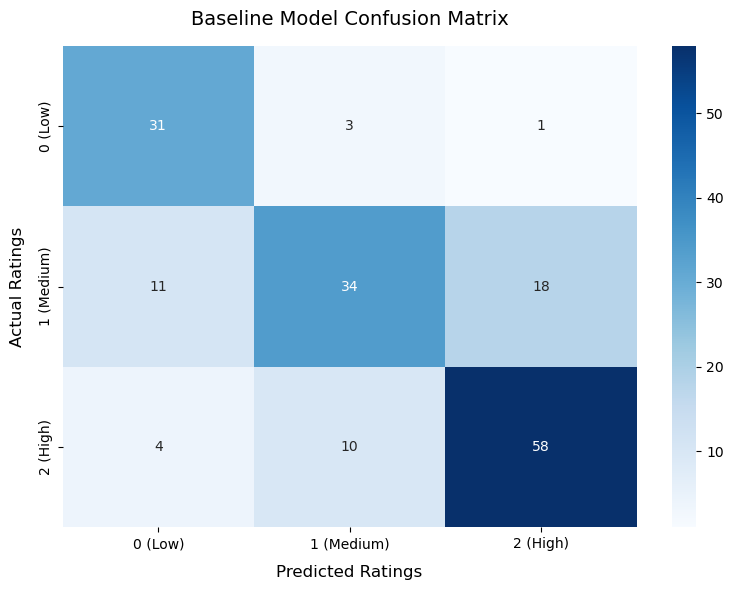

In [49]:
# 1. Generate the raw confusion matrix array
cm = confusion_matrix(y_test, y_pred)

# 2. Define your class labels (0, 1, 2 for ratings)
class_labels = ['0 (Low)', '1 (Medium)', '2 (High)']

# 3. Plot the matrix using a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm, 
    annot=True,          # Shows the raw count numbers inside the squares
    fmt='d',             # Formats numbers as integers instead of decimals
    cmap='Blues',        # Uses a clean blue color gradient
    xticklabels=class_labels, 
    yticklabels=class_labels
)

# 4. Add clear structural labels
plt.title('Baseline Model Confusion Matrix', fontsize=14, pad=15)
plt.xlabel('Predicted Ratings', fontsize=12, labelpad=10)
plt.ylabel('Actual Ratings', fontsize=12, labelpad=10)
plt.tight_layout()
plt.show()

### Baseline Model Performance Analysis

The Logistic Regression model (configured with balanced class weights) achieved an overall baseline accuracy of **72.35%**. Given that a random guess across three classes would yield 33.3% accuracy, this baseline demonstrates strong initial predictive power.

#### Key Observations

* **Exceptional Minority Class Recall (Class 0):** 
  The model achieves its highest recall (**89%**) on low-rated restaurants (`0`). It successfully captures almost all poorly rated venues, meaning it rarely misses a bad restaurant. This is a direct benefit of using `class_weight='balanced'`.

* **Strong High-Rating Predictability (Class 2):** 
  High-rated restaurants (`2`) show balanced, robust performance with **75% precision** and **81% recall** (F1-score: **0.78**). The model is reliable when recommending top-tier venues.

* **Mid-Tier Confusion (Class 1):** 
  The model struggles significantly with medium-rated venues (`1`), yielding a low recall of **54%**. It correctly identifies barely half of them, frequently misclassifying them as either low or high. 

* **Balanced Macro Performance:** 
  The **Macro F1-Score of 0.72** confirms that the model performs consistently across the classes despite the slight dataset imbalance.


In [52]:
# Save engineered dataset
df.to_csv("../data/processed/chefmoz_engineered.csv", index=False)